In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Read Data

dataset = pd.read_csv("../data/features/metadata.csv")

print(dataset["background_father"].unique())
dataset.replace("UNK", np.nan, inplace = True)
dataset["background_father"] = dataset["background_father"].ffill().bfill()
dataset["background_mother"] = dataset["background_mother"].ffill().bfill()

[nan 'POMERANIA' 'GERMANY' 'BRAZIL' 'NETHERLANDS' 'ITALY' 'POLAND' 'UNK'
 'PORTUGAL' 'BRASIL' 'CZECH' 'AUSTRIA' 'SPAIN' 'ISRAEL']


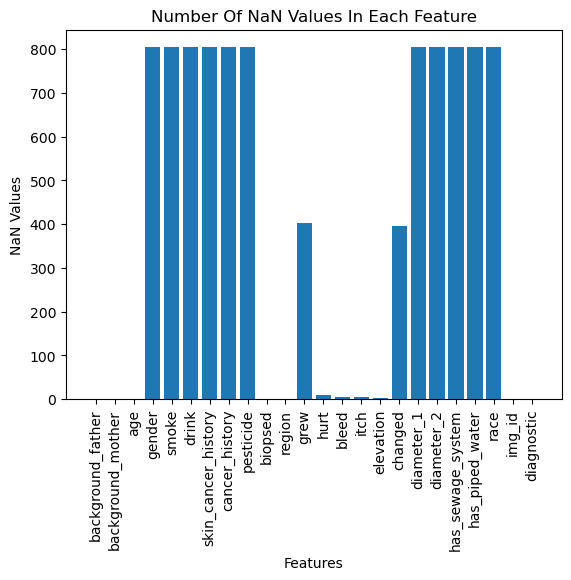

In [106]:
# NaN Values Visualization

columns = dataset.isnull().sum().keys()
values = dataset.isnull().sum().values

plt.bar(columns, values)
plt.title("Number Of NaN Values In Each Feature")
plt.xlabel("Features")
plt.ylabel("NaN Values")
plt.xticks(rotation = 90)
plt.show()

C:\Users\Moham\AppData\Local\Temp\ipykernel_14464\2526030934.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


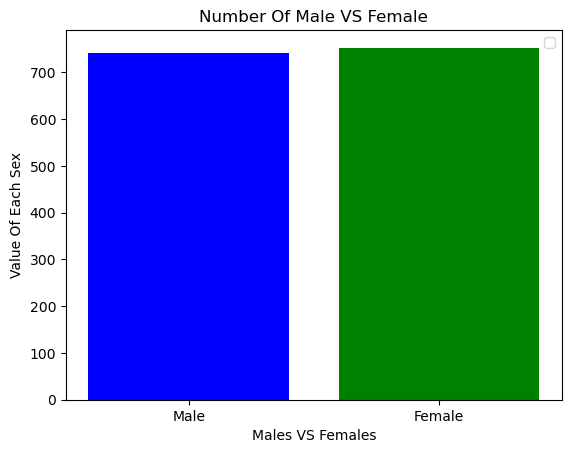

In [107]:
# Labeld Data

# MALE: 1, FEMALE: 0
dataset["gender"] = dataset["gender"].map({"MALE": 1, "FEMALE": 0})

sexCount = [(dataset["gender"] == 1).sum(), (dataset["gender"] == 0).sum()]
plt.bar(["Male", "Female"], sexCount, color = ["blue", "green"])
plt.title("Number Of Male VS Female")
plt.xlabel("Males VS Females")
plt.ylabel("Value Of Each Sex")
plt.legend()
plt.show()

# TRUE: 1, FALSE: 0
binaryColumns = ["smoke", "drink", "skin_cancer_history", "cancer_history", "pesticide", "biopsed", "grew", 
                 "hurt", "bleed", "itch", "elevation", "changed", "has_sewage_system", "has_piped_water"]

for column in binaryColumns:
  if(dataset[column].dtype == bool):
    dataset[column] = dataset[column].map({True: 1, False: 0})


for column in binaryColumns:
  if(dataset[column].dtype == object):
    dataset[column] = dataset[column].astype(str).str.upper().str.strip().map({"TRUE": 1, "FALSE": 0})

# Mode Metohd
mode_value = dataset["region"].mode()[0]
dataset["region"] = dataset["region"].fillna(mode_value)
dataset = pd.get_dummies(data = dataset, columns = ["region"], dtype = int, drop_first = True)

In [108]:
# Process Gender

from sklearn.impute import KNNImputer

region_cols = [col for col in dataset.columns if col.startswith("region")]
featreus = ["age", "biopsed"] + region_cols

imputer = KNNImputer(n_neighbors = 10)
dataset[["gender"]] = imputer.fit_transform(dataset[["gender"] + featreus])[:, 0:1]
dataset["gender"] = dataset["gender"].round().astype(int)

In [109]:
# KNNImputer

knnCols = dataset.drop(columns = ["gender", "img_id", "diagnostic", "background_father", "background_mother"]).columns
print(knnCols)
knnImputer = KNNImputer(missing_values = np.nan, n_neighbors = 5, weights = "uniform")

male_gender = dataset["gender"] == 1
dataset.loc[male_gender, knnCols] = knnImputer.fit_transform(dataset.loc[male_gender, knnCols])

female_gender = dataset["gender"] == 0
dataset.loc[female_gender, knnCols] = knnImputer.fit_transform(dataset.loc[female_gender, knnCols])

Index(['age', 'smoke', 'drink', 'skin_cancer_history', 'cancer_history',
       'pesticide', 'biopsed', 'grew', 'hurt', 'bleed', 'itch', 'elevation',
       'changed', 'diameter_1', 'diameter_2', 'has_sewage_system',
       'has_piped_water', 'race', 'region_ARM', 'region_BACK', 'region_CHEST',
       'region_EAR', 'region_FACE', 'region_FOOT', 'region_FOREARM',
       'region_HAND', 'region_LIP', 'region_NECK', 'region_NOSE',
       'region_SCALP', 'region_THIGH'],
      dtype='object')


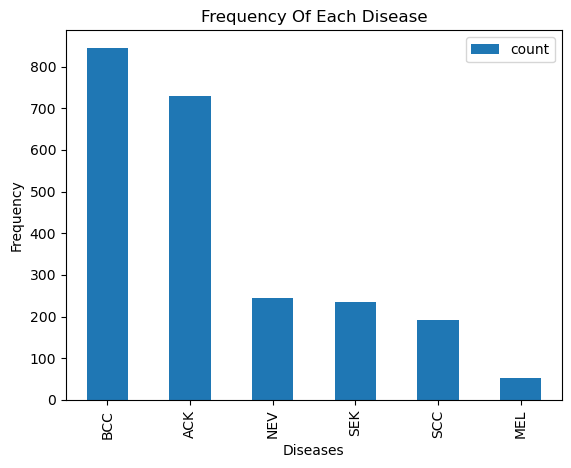

In [110]:
# Diseases Visualization

diseases_count = dataset["diagnostic"].value_counts()

diseases_count.plot(kind = "bar")
plt.title("Frequency Of Each Disease")
plt.xlabel("Diseases")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [111]:
dataset["diagnostic"].value_counts()

diagnostic
BCC    845
ACK    730
NEV    244
SEK    235
SCC    192
MEL     52
Name: count, dtype: int64

In [112]:
# Normalization

from sklearn.preprocessing import StandardScaler

normColumns = ["age", "diameter_1", "diameter_2"]
sc = StandardScaler()
dataset[normColumns] = sc.fit_transform(dataset[normColumns])

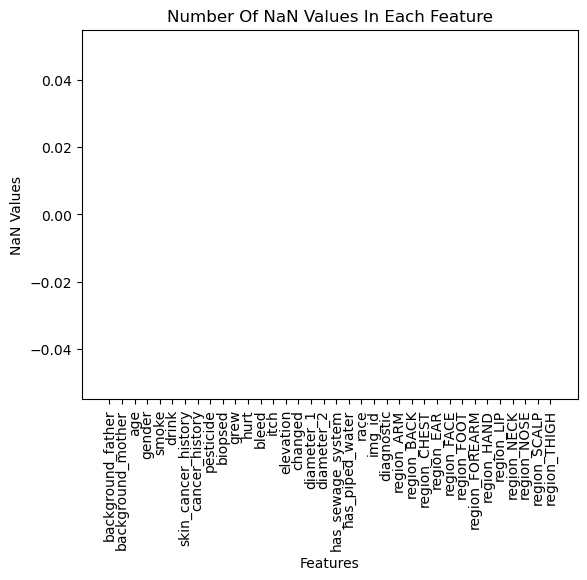

In [113]:
# NaN Values Visualization

columns = dataset.isnull().sum().keys()
values = dataset.isnull().sum().values

plt.bar(columns, values)
plt.title("Number Of NaN Values In Each Feature")
plt.xlabel("Features")
plt.ylabel("NaN Values")
plt.xticks(rotation = 90)
plt.show()

In [ ]:
# Export Dataset, Standard Scalers

import pickle

with open("../data/features/dataset.pkl", "wb") as f:
  pickle.dump(dataset, f)

with open("../saved_models/sc.pkl", "wb") as f:
  pickle.dump(sc, f)